In [1]:
REPO = '../'
RESULT_TABLE = f'{REPO}/data/table'
RESULT_OBJ = f'{REPO}/data/object'
FIGURE_FOLDER= f'{REPO}/data/figure'
SETTING_FOLDER = f'{REPO}/data/setting'
EXTERNAL_DATA=f'{REPO}/data/external'


import sys
sys.path.append(REPO)
from settings import COLOR_PAlETTE
from utils.visual import *
from utils.statsTest import lmTest

import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scPipe as sp
import scanpy as sc
import seaborn as sns
import warnings
import commentjson
### Additional Colormap
with open(f'{SETTING_FOLDER}/ColorMap.json','r') as f:
    colormap = commentjson.load(f)
COLOR_PAlETTE.update(colormap)
plt.style.use(f'{REPO}/paper.mplstyle')
warnings.filterwarnings("ignore")
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
Celltype = 'Macs'
adata = sc.read(f'{RESULT_OBJ}/gex_all.h5ad')
obs = pd.read_csv(f"{RESULT_TABLE}/MPs/{Celltype}/Annotation.csv",index_col=0)
sample_meta = pd.read_excel(f'{RESULT_TABLE}/Supplementary Table 1.xlsx',index_col=0).replace(np.nan,'N/A')

adata = adata[adata.obs.index.isin(obs.index),:]
adata.obs['Cellstate'] = obs.loc[adata.obs.index,'Cellstate']
adata.obs = adata.obs.merge(sample_meta,left_on='Sample',right_on='CCG_ID')
print(f'{adata.obs.shape[0]:,} {Celltype} cells')
adata.obs['Cellstate'].value_counts()

13,375 Macs cells


Macs.Lipid          5291
Macs.Adhesion       2637
Macs.Endocytosis    2519
Macs.Interferon     1764
Macs.Secretion      1164
Name: Cellstate, dtype: int64

In [3]:
cellstate_list = adata.obs['Cellstate'].unique()
ra_prop = (
    pd.crosstab([adata.obs['Patient'],adata.obs['Timepoint'],adata.obs['BestResponse']],adata.obs['Cellstate']).
    reindex(pd.Index(sample_meta[['Patient','Timepoint','BestResponse']].drop_duplicates()))
)
ra_prop =  (ra_prop.div(ra_prop.sum(axis=1).replace(0, 1e-6), axis=0) * 100).reset_index()
ra_prop.Timepoint = ra_prop.Timepoint.replace({'W3D1':'On-Monotherapy','W7D1':'On-Combination'})
ra_prop.head()

Cellstate,Patient,Timepoint,BestResponse,Macs.Adhesion,Macs.Endocytosis,Macs.Interferon,Macs.Lipid,Macs.Secretion
0,P01,Baseline,favorable response\n(RCB 0-I),32.799014,1.849568,5.055487,54.870530,5.425401
1,P01,On-Monotherapy,favorable response\n(RCB 0-I),11.451613,6.129032,20.967742,56.290323,5.161290
2,P01,On-Combination,favorable response\n(RCB 0-I),0.938567,0.255973,7.593857,90.784983,0.426621
3,P07,On-Monotherapy,favorable response\n(RCB 0-I),9.165903,1.833181,19.110907,60.311641,9.578368
4,P07,On-Combination,favorable response\n(RCB 0-I),33.532934,31.137725,8.383234,13.772455,13.173653


## Explore the trend by percentages

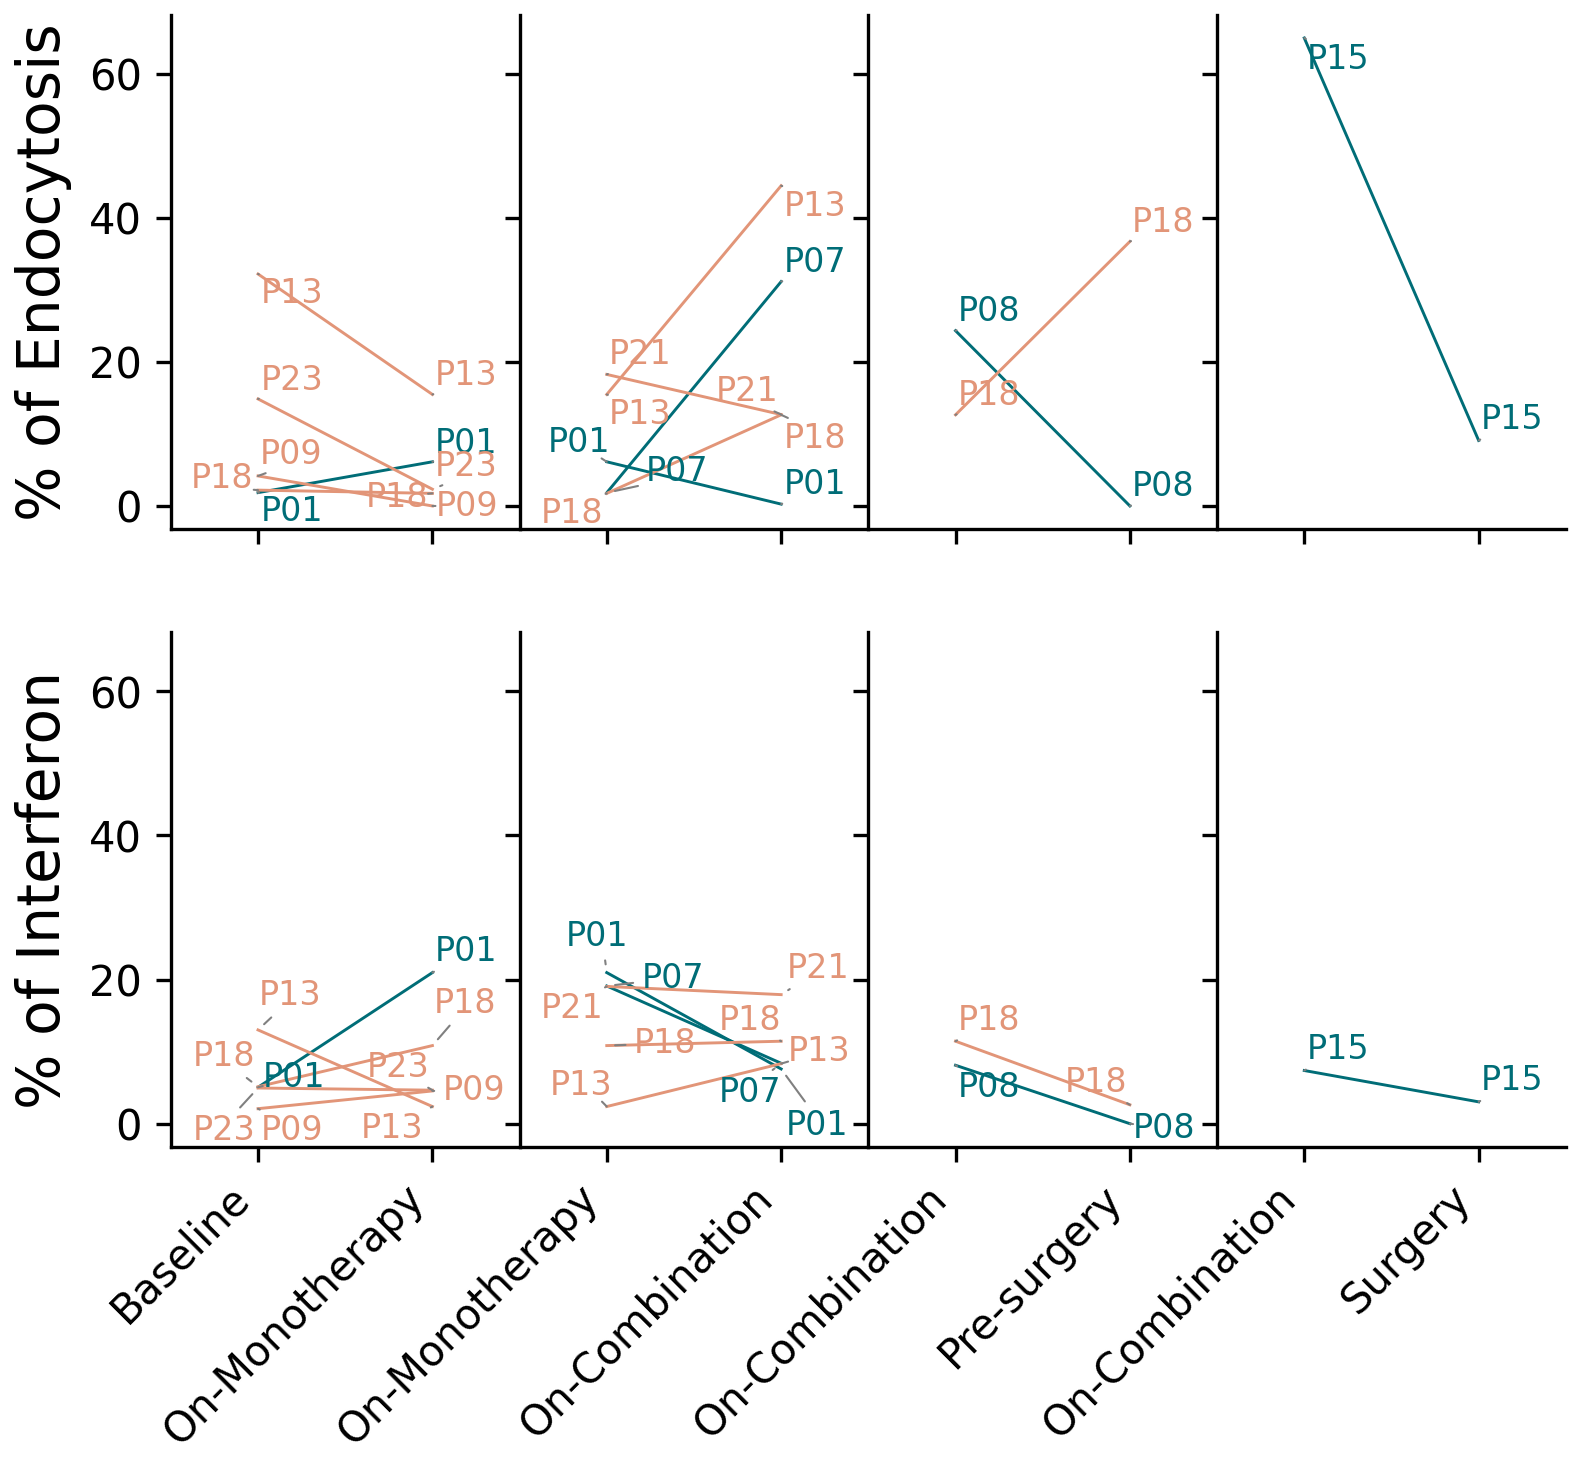

In [9]:
cellstate_list = ['Macs.Endocytosis','Macs.Interferon']
from adjustText import adjust_text
fig, axs = plt.subplots(len(cellstate_list),4, figsize=(6,1+len(cellstate_list)*2), sharey=True,dpi=300)

colormap = sample_meta[['Patient','BestResponse']].drop_duplicates().set_index(
    "Patient"
)['BestResponse'].map(COLOR_PAlETTE['BestResponse']).to_dict()
for i, cellstate in enumerate(cellstate_list):
    for j, pairs in enumerate([['Baseline','On-Monotherapy'], ['On-Monotherapy','On-Combination'], ['On-Combination','Pre-surgery'], ['On-Combination','Surgery']]):
        # Data filtering
        data = ra_prop.loc[ra_prop.Timepoint.isin(pairs), :]
        n_sample = data['Patient'].value_counts()
        keep_pt = n_sample[n_sample == 2].index
        data = data.loc[data['Patient'].isin(keep_pt), :]
        # Create plot
        ax = axs[i,j]
        sns.pointplot(
            data=data,
            x='Timepoint',
            y=cellstate,
            order=pairs,
            hue='Patient',
            palette=colormap,
            ax=ax,
            markers='',  # Remove default markers
            linestyles='-',  # Keep connection lines,
            lw=.7
        )
        # Add Patient ID text labels
        texts = []
        for patient in keep_pt:
            # Get coordinates for both timepoints
            patient_data = data.loc[data['Patient'] == patient,:]
            for timepoint in pairs:

                x = pairs.index(timepoint)  # 0 for first timepoint, 1 for second
                y = patient_data[patient_data['Timepoint'] == timepoint][cellstate].values[0]
                
                texts.append(ax.text(
                    x, y, 
                    patient,
                    ha='center', 
                    va='bottom', 
                    fontsize=8,
                    color=colormap.get(patient, 'black')
                ))

        # Automatically adjust text positions
        adjust_text(texts, 
                   ax=ax,
                   force_text=(0.5, 0.8),  # Horizontal/vertical force for text movement
                   force_points=(0.1, 0.5),  # Force keeping text near original point
                   expand_points=(1.1, 1.3),  # Expand search radius
                   arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
                   lim=10  # Max iterations
                  )
        ax.set_xlabel('')
        ax.set_ylabel(f"% of {cellstate.replace(Celltype+'.','')}", fontsize=14)
        ax.get_legend().remove()  # Remove redundant legend
        if i < len(cellstate_list)-1:
            ax.set_xticklabels([])
        else:
            ax.set_xticklabels(
                ax.get_xticklabels(),
                rotation=45,          
                ha='right',       
            )

plt.subplots_adjust(wspace=0)
fig.savefig(f'{FIGURE_FOLDER}/{Celltype}_MP_Distribution_By_Patient_R_and_NR.pdf',dpi=150,bbox_inches='tight')
